In [1]:
import os
import torch
import warnings
import chunking as C
from tqdm import tqdm
from pathlib import Path
from torch import nn, optim
from resnet20 import resnet20
import torch.nn.functional as F
import json, random, numpy as np
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR100
from transformer_vae import TVAE, vae_loss
from torch.utils.data import DataLoader, Dataset
from constants import SEED, device, TOKENS_PER_SEQ
from dataset import ResZoo, summon_res_zoo
warnings.filterwarnings("ignore")

### Load the data & Data loaders

- `train_loader`: 27 checkpoints from experts 0–2, ~3,213 sequences.
  Shuffled, `drop_last=True` for consistent batch shapes.
- `validation_loader`: expert 3, never trained on. Used to select the epoch
  and, later, the compression ratio.
- `test_loader`: expert 4, held out entirely. Touched **once**, for the
  final reported generalization number.
- `merge_loader`: the five `ep040` checkpoints. These are experiment
  subjects, not training data, and are excluded from VAE training so the
  encoder cannot have memorized the exact weights we later merge.

At batch size 64 the training set is ~50 steps per epoch, so epochs are cheap
and we can afford 200 of them.

In [30]:
zoo_dir = './zoo_chunks'
training_set, validation_set, test_set, merge_set = summon_res_zoo('./zoo_chunks')
train_dataset = ResZoo(root_dir=zoo_dir, model_ids=training_set)
validation_dataset = ResZoo(root_dir=zoo_dir, model_ids=validation_set)
test_dataset = ResZoo(root_dir=zoo_dir, model_ids=test_set)
merge_dataset = ResZoo(root_dir=zoo_dir, model_ids=merge_set)

backbone_dataset = ResZoo(root_dir='./zoo_reference', model_ids=['backbone_a',])

print(f'train {len(training_set)}  val {len(validation_set)}  ', f'test {len(test_set)}  merge {len(merge_set)}')

train 27  val 9   test 10  merge 5


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
validation_loader = DataLoader(validation_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
merge_loader = DataLoader(merge_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

### Train the TVAE model

## Stage A: Deterministic autoencoder (`r = 1`, KL off)

I train the transformer VAE with **both** of its regularizing knobs disabled:

| Knob | Setting | Meaning |
|---|---|---|
| `latent_dim = 144` | `r = 144/144 = 1` | no bottleneck, the latent is as wide as the input |
| `BETA = 0.0` | KL term off | no pull toward `N(0,1)`, so this is a plain autoencoder |


In [ ]:
EPOCHS = 200
BETA = 0.0            

tvae_model = TVAE(input_dim=144, model_dim=256, latent_dim=144).to(device)
optimizer = optim.AdamW(tvae_model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

In [ ]:
@torch.no_grad()
def eval_recon(model, loader, beta=0.0):
    '''eval mode makes reparameterize return mu, so reconstruction is deterministic'''
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        chunks = batch['chunks'].to(device, non_blocking=True)
        mask = batch['mask'].to(device, non_blocking=True)
        depth = batch['depth'].to(device, non_blocking=True)
        stage = batch['stage'].to(device, non_blocking=True)
        xhat, mu, logvar = model(chunks, depth, stage)
        _, recon, _ = vae_loss(xhat, chunks, mu, logvar, mask, beta)
        total += recon.item(); n += 1
    return total / max(n, 1)

In [6]:
best_val = float('inf')

for epoch in range(EPOCHS):
    tvae_model.train()
    running_recon, running_kl, n = 0.0, 0.0, 0

    for batch in train_loader:
        chunks = batch['chunks'].to(device, non_blocking=True)
        mask = batch['mask'].to(device, non_blocking=True)
        depth = batch['depth'].to(device, non_blocking=True)
        stage = batch['stage'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        '''forward returns three things, not one'''
        xhat, mu, logvar = tvae_model(chunks, depth, stage)
        loss, recon, kl = vae_loss(xhat, chunks, mu, logvar, mask, BETA)
        loss.backward()
        '''clip so a rare outlier chunk cannot blow up a step'''
        torch.nn.utils.clip_grad_norm_(tvae_model.parameters(), 1.0)
        optimizer.step()

        running_recon += recon.item(); running_kl += kl.item(); n += 1

    scheduler.step()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        val_recon = eval_recon(tvae_model, validation_loader, BETA)
        print(f'epoch {epoch+1:3d}/{EPOCHS}  train recon {running_recon/n:.5f}  '
              f'val recon {val_recon:.5f}  kl {running_kl/n:.2f}  '
              f'lr {scheduler.get_last_lr()[0]:.2e}')

        if val_recon < best_val:
            best_val = val_recon
            torch.save({
                'state_dict': tvae_model.state_dict(),
                'epoch': epoch + 1,
                'val_recon': val_recon,
                'latent_dim': tvae_model.latent_dim,
                'beta': BETA,
            }, './res_models/tvae_r1.pt')

print(f'done, best val recon {best_val:.5f}')

epoch   1/200  train recon 0.42345  val recon 0.36817  kl 62.32  lr 1.00e-04
epoch   5/200  train recon 0.15689  val recon 0.12502  kl 198.87  lr 9.98e-05
epoch  10/200  train recon 0.04864  val recon 0.04388  kl 407.26  lr 9.94e-05
epoch  15/200  train recon 0.02214  val recon 0.02184  kl 489.01  lr 9.86e-05
epoch  20/200  train recon 0.01197  val recon 0.01324  kl 536.27  lr 9.76e-05
epoch  25/200  train recon 0.00717  val recon 0.00878  kl 572.02  lr 9.62e-05
epoch  30/200  train recon 0.00502  val recon 0.00675  kl 598.44  lr 9.46e-05
epoch  35/200  train recon 0.00364  val recon 0.00558  kl 620.95  lr 9.26e-05
epoch  40/200  train recon 0.00293  val recon 0.00504  kl 638.82  lr 9.05e-05
epoch  45/200  train recon 0.00245  val recon 0.00444  kl 654.15  lr 8.80e-05
epoch  50/200  train recon 0.00216  val recon 0.00407  kl 668.80  lr 8.54e-05
epoch  55/200  train recon 0.00197  val recon 0.00392  kl 680.95  lr 8.25e-05
epoch  60/200  train recon 0.00174  val recon 0.00366  kl 692.98 

In [37]:

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

EXPERT_COLORS = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868', 3: '#C44E52', 4: '#8172B3'}
BACKBONE_LABEL = -1


@torch.no_grad()
def collect_latents(model, dataset, batch_size=64):
    '''eval mode so reparameterize returns mu, embeddings must be deterministic'''
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    lat, depths, stages, model_idx = [], [], [], []
    for batch in loader:
        '''encode only, we want mu not a decoded reconstruction'''
        mu, _ = model.encode(
            batch['chunks'].to(device),
            batch['depth'].to(device),
            batch['stage'].to(device))
        lat.append(mu.cpu().numpy())
        depths.append(batch['depth'].numpy())
        stages.append(batch['stage'].numpy())
        model_idx.append(batch['model_idx'].numpy())

    lat = np.concatenate(lat)
    return (lat, np.concatenate(depths), np.concatenate(stages),
            np.concatenate(model_idx))


def reduce_2d(L, seed=0, perplexity=30):
    '''flatten the token axis so one sequence becomes one point'''
    X = L.reshape(len(L), -1)
    '''pca first, t-sne on raw high dimensional data is slow and picks up noise'''
    n_pc = min(50, X.shape[1], len(X) - 1)
    X = PCA(n_components=n_pc, random_state=seed).fit_transform(X)
    '''perplexity must stay below a third of the sample count'''
    perp = min(perplexity, max(5, (len(X) - 1) // 3))
    return TSNE(n_components=2, perplexity=perp, init='pca',
                random_state=seed).fit_transform(X)

In [38]:
def build_latents(model, zoo_dir, model_ids, reference_dir=None, reference_ids=None):
    '''backbone lives under a different root and its split_id is the string 'full',
    so it is built separately and merged at the array level'''
    ds = ResZoo(root_dir=zoo_dir, model_ids=model_ids)
    lat, depths, stages, midx = collect_latents(model, ds)
    splits = np.array([int(ds.meta_list[m].split_id) for m in midx])

    if reference_dir is not None and reference_ids:
        ds_ref = ResZoo(root_dir=reference_dir, model_ids=reference_ids)
        l2, d2, s2, m2 = collect_latents(model, ds_ref)
        lat = np.concatenate([lat, l2])
        depths = np.concatenate([depths, d2])
        stages = np.concatenate([stages, s2])
        '''label the backbone -1 so it never collides with a real expert id'''
        splits = np.concatenate([splits, np.full(len(m2), BACKBONE_LABEL)])

    return lat, depths, stages, splits


def plot_depth_grid(lat, depths, splits, depth_list, n_cols=3, tag='',
                    seed=0, perplexity=20, savepath=None):
    n_rows = int(np.ceil(len(depth_list) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4.2 * n_cols, 3.6 * n_rows), squeeze=False)

    for k, d in enumerate(depth_list):
        ax = axes[k // n_cols][k % n_cols]
        sel = np.where(depths == d)[0]
        if len(sel) < 6:
            ax.set_title(f'depth {d}: too few points')
            ax.axis('off')
            continue

        emb = reduce_2d(lat[sel], seed, perplexity)
        lbl = splits[sel]
        for sp in sorted(set(lbl) - {BACKBONE_LABEL}):
            m = lbl == sp
            ax.scatter(emb[m, 0], emb[m, 1], c=EXPERT_COLORS[sp],
                       s=12, alpha=0.7, label=f'expert {sp}')

        '''backbone drawn last so it stays visible on top of the clusters'''
        mb = lbl == BACKBONE_LABEL
        if mb.any():
            ax.scatter(emb[mb, 0], emb[mb, 1], c='black', marker='*', s=90,
                       zorder=5, label='backbone', edgecolors='white', linewidths=0.4)

        ax.set_title(f'depth {d}', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

    for k in range(len(depth_list), n_rows * n_cols):
        axes[k // n_cols][k % n_cols].axis('off')

    h, l = axes[0][0].get_legend_handles_labels()
    fig.legend(h, l, loc='lower center', ncol=len(l), fontsize=9, frameon=False)
    fig.suptitle(f'Latents by depth{tag}', fontsize=12)
    fig.tight_layout(rect=[0, 0.05, 1, 0.97])
    if savepath:
        fig.savefig(savepath, dpi=150)
    plt.show()
    return fig


def expert_separation(lat, depths, splits, depth_list, exclude_backbone=True, verbose=True):
    '''within vs between expert distance, t-sne separation on few points is unreliable
    so this is the number to trust rather than the picture'''
    rows = []
    for d in depth_list:
        sel = np.where(depths == d)[0]
        lbl = splits[sel]
        if exclude_backbone:
            keep = lbl != BACKBONE_LABEL
            sel, lbl = sel[keep], lbl[keep]
        if len(sel) < 2:
            continue
        X = lat[sel].reshape(len(sel), -1)
        '''vectorized pairwise distances, the double loop is far too slow at this size'''
        D = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=-1)
        iu = np.triu_indices(len(X), k=1)
        same = lbl[:, None] == lbl[None, :]
        w = D[iu][same[iu]].mean()
        b = D[iu][~same[iu]].mean()
        rows.append((d, w, b, b / w))
        if verbose:
            print(f'depth {d:>2}: within {w:8.3f}  between {b:8.3f}  ratio {b/w:.3f}')
    return rows


def backbone_distance(lat, depths, splits, depth_list, verbose=True):
    '''the backbone is the common ancestor so it should sit near the expert centroid'''
    rows = []
    for d in depth_list:
        sel = np.where(depths == d)[0]
        if len(sel) == 0:
            continue
        X = lat[sel].reshape(len(sel), -1)
        lbl = splits[sel]
        bb = X[lbl == BACKBONE_LABEL]
        if len(bb) == 0:
            continue
        experts = sorted(set(lbl) - {BACKBONE_LABEL})
        dists = [np.linalg.norm(bb[:, None, :] - X[lbl == sp][None, :, :], axis=-1).mean()
                 for sp in experts]
        rows.append((d, experts, dists))
        if verbose:
            print(f'depth {d:>2}: backbone to experts ' +
                  '  '.join(f'e{sp}={v:7.3f}' for sp, v in zip(experts, dists)))
    return rows

In [39]:
def build_latents(model, zoo_dir, model_ids, reference_dir=None, reference_ids=None):
    '''backbone lives under a different root and its split_id is the string 'full',
    so it is built separately and merged at the array level'''
    ds = ResZoo(root_dir=zoo_dir, model_ids=model_ids)
    lat, depths, stages, midx = collect_latents(model, ds)
    splits = np.array([int(ds.meta_list[m].split_id) for m in midx])

    if reference_dir is not None and reference_ids:
        ds_ref = ResZoo(root_dir=reference_dir, model_ids=reference_ids)
        l2, d2, s2, m2 = collect_latents(model, ds_ref)
        lat = np.concatenate([lat, l2])
        depths = np.concatenate([depths, d2])
        stages = np.concatenate([stages, s2])
        '''label the backbone -1 so it never collides with a real expert id'''
        splits = np.concatenate([splits, np.full(len(m2), BACKBONE_LABEL)])

    return lat, depths, stages, splits


def plot_depth_grid(lat, depths, splits, depth_list, n_cols=3, tag='',
                    seed=0, perplexity=20, savepath=None):
    n_rows = int(np.ceil(len(depth_list) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4.2 * n_cols, 3.6 * n_rows), squeeze=False)

    for k, d in enumerate(depth_list):
        ax = axes[k // n_cols][k % n_cols]
        sel = np.where(depths == d)[0]
        if len(sel) < 6:
            ax.set_title(f'depth {d}: too few points')
            ax.axis('off')
            continue

        emb = reduce_2d(lat[sel], seed, perplexity)
        lbl = splits[sel]
        for sp in sorted(set(lbl) - {BACKBONE_LABEL}):
            m = lbl == sp
            ax.scatter(emb[m, 0], emb[m, 1], c=EXPERT_COLORS[sp],
                       s=12, alpha=0.7, label=f'expert {sp}')

        '''backbone drawn last so it stays visible on top of the clusters'''
        mb = lbl == BACKBONE_LABEL
        if mb.any():
            ax.scatter(emb[mb, 0], emb[mb, 1], c='black', marker='*', s=90,
                       zorder=5, label='backbone', edgecolors='white', linewidths=0.4)

        ax.set_title(f'depth {d}', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

    for k in range(len(depth_list), n_rows * n_cols):
        axes[k // n_cols][k % n_cols].axis('off')

    h, l = axes[0][0].get_legend_handles_labels()
    fig.legend(h, l, loc='lower center', ncol=len(l), fontsize=9, frameon=False)
    fig.suptitle(f'Latents by depth{tag}', fontsize=12)
    fig.tight_layout(rect=[0, 0.05, 1, 0.97])
    if savepath:
        fig.savefig(savepath, dpi=150)
    plt.show()
    return fig


def expert_separation(lat, depths, splits, depth_list, exclude_backbone=True, verbose=True):
    '''within vs between expert distance, t-sne separation on few points is unreliable
    so this is the number to trust rather than the picture'''
    rows = []
    for d in depth_list:
        sel = np.where(depths == d)[0]
        lbl = splits[sel]
        if exclude_backbone:
            keep = lbl != BACKBONE_LABEL
            sel, lbl = sel[keep], lbl[keep]
        if len(sel) < 2:
            continue
        X = lat[sel].reshape(len(sel), -1)
        '''vectorized pairwise distances, the double loop is far too slow at this size'''
        D = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=-1)
        iu = np.triu_indices(len(X), k=1)
        same = lbl[:, None] == lbl[None, :]
        w = D[iu][same[iu]].mean()
        b = D[iu][~same[iu]].mean()
        rows.append((d, w, b, b / w))
        if verbose:
            print(f'depth {d:>2}: within {w:8.3f}  between {b:8.3f}  ratio {b/w:.3f}')
    return rows


def backbone_distance(lat, depths, splits, depth_list, verbose=True):
    '''the backbone is the common ancestor so it should sit near the expert centroid'''
    rows = []
    for d in depth_list:
        sel = np.where(depths == d)[0]
        if len(sel) == 0:
            continue
        X = lat[sel].reshape(len(sel), -1)
        lbl = splits[sel]
        bb = X[lbl == BACKBONE_LABEL]
        if len(bb) == 0:
            continue
        experts = sorted(set(lbl) - {BACKBONE_LABEL})
        dists = [np.linalg.norm(bb[:, None, :] - X[lbl == sp][None, :, :], axis=-1).mean()
                 for sp in experts]
        rows.append((d, experts, dists))
        if verbose:
            print(f'depth {d:>2}: backbone to experts ' +
                  '  '.join(f'e{sp}={v:7.3f}' for sp, v in zip(experts, dists)))
    return rows

latents (4403, 16, 144)  labels [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]  (-1 = backbone)


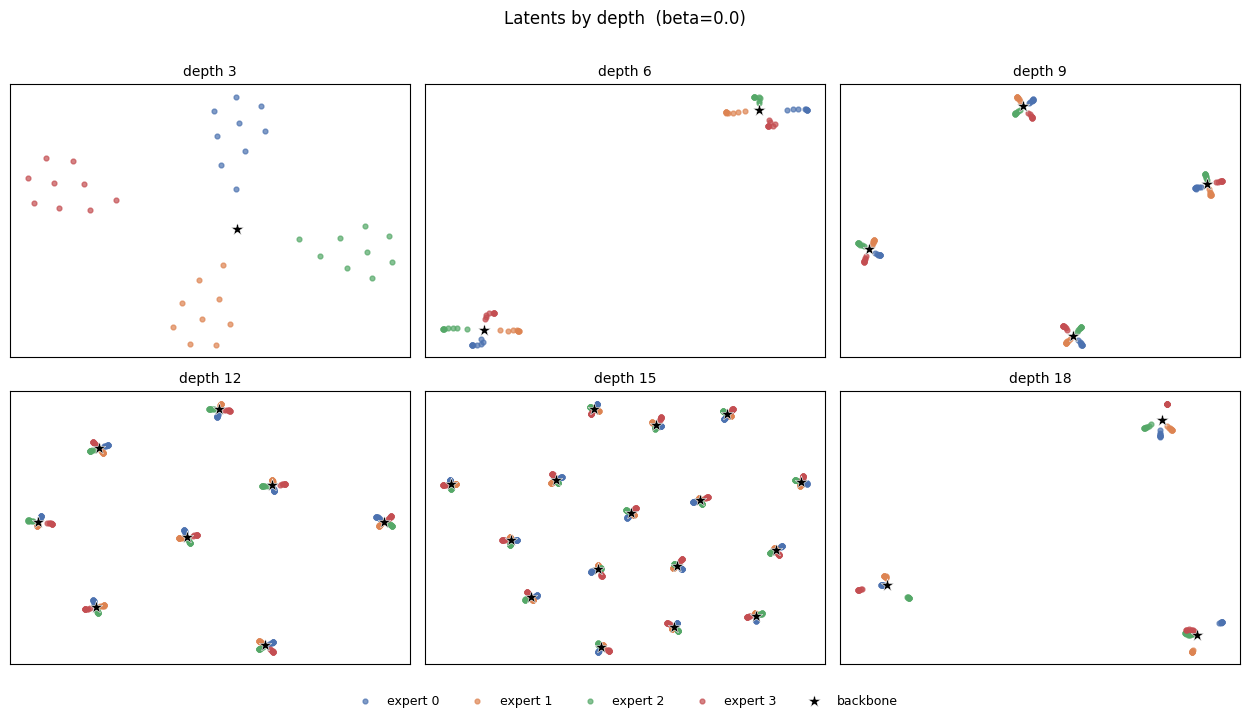


depth  3: within    2.442  between    7.687  ratio 3.148
depth  6: within   23.892  between   24.560  ratio 1.028
depth  9: within   37.168  between   37.790  ratio 1.017
depth 12: within   41.283  between   41.479  ratio 1.005
depth 15: within   43.554  between   43.685  ratio 1.003
depth 18: within   30.289  between   30.114  ratio 0.994

depth  3: backbone to experts e0=  5.309  e1=  5.066  e2=  5.566  e3=  5.815
depth  6: backbone to experts e0= 23.724  e1= 23.587  e2= 23.729  e3= 23.764
depth  9: backbone to experts e0= 37.092  e1= 36.973  e2= 37.087  e3= 37.299
depth 12: backbone to experts e0= 41.231  e1= 41.145  e2= 41.173  e3= 41.228
depth 15: backbone to experts e0= 43.507  e1= 43.486  e2= 43.486  e3= 43.526
depth 18: backbone to experts e0= 29.752  e1= 29.786  e2= 29.745  e3= 29.824


[(3,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(5.3087606),
   np.float32(5.0656786),
   np.float32(5.5664115),
   np.float32(5.8146167)]),
 (6,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(23.723726),
   np.float32(23.587084),
   np.float32(23.729301),
   np.float32(23.764008)]),
 (9,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(37.091766),
   np.float32(36.973248),
   np.float32(37.087227),
   np.float32(37.299484)]),
 (12,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(41.231316),
   np.float32(41.145344),
   np.float32(41.17282),
   np.float32(41.227894)]),
 (15,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(43.506573),
   np.float32(43.486057),
   np.float32(43.485977),
   np.float32(43.526413)]),
 (18,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(29.751595),
   np.float32(29.785784),
   np.float32(29.745298),
   np.float32(29.824451)

In [47]:
BETA = 0.0

ALL_DEPTHS = list(range(3,19,3))

lat, depths, stages, splits = build_latents(
    tvae_model, zoo_dir, training_set + validation_set,
    reference_dir='./zoo_reference', reference_ids=['backbone_a'])

print(f'latents {lat.shape}  labels {sorted(set(splits))}  '
     f'({BACKBONE_LABEL} = backbone)')

plot_depth_grid(lat, depths, splits, ALL_DEPTHS, n_cols=3,
                tag=f'  (beta={BETA})', savepath=f'latent_grid_beta{BETA}.png')

print()
expert_separation(lat, depths, splits, ALL_DEPTHS)
print()
backbone_distance(lat, depths, splits, ALL_DEPTHS)